In [21]:
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt

In [22]:
WIDTH  = 640
HEIGHT = 480

DUMP_PATH = "./left_large.bin"
FORMAT    = "auto"             # auto | raw16le | raw32le_words | hex16_text | hex32_text | mb_printf

# If your dump uses 32-bit words (two pixels per word), pick pixel order:
# lohi = first pixel in low 16 bits, second pixel in high 16 bits
# hilo = first pixel in high 16 bits, second pixel in low 16 bits
PIXEL_ORDER = "lohi"

# Flip options (if your camera/HDL flips)
FLIP_H = False
FLIP_V = False

SAVE_PNG = False
OUT_PNG_PATH = "rendered_frame.png"

In [23]:
def rgb565_to_rgb888(img565: np.ndarray) -> np.ndarray:
    """img565: uint16 (H,W) -> uint8 (H,W,3)"""
    img565 = img565.astype(np.uint16)
    r = ((img565 >> 11) & 0x1F) * 255 // 31
    g = ((img565 >> 5)  & 0x3F) * 255 // 63
    b = ( img565        & 0x1F) * 255 // 31
    return np.stack([r, g, b], axis=-1).astype(np.uint8)

def _extract_hex_tokens(text: str):
    # Matches 0xDEADBEEF, DEADBEEF, f81f, etc. (4 to 8 hex digits)
    return re.findall(r"(?:0x)?([0-9A-Fa-f]{4,8})", text)

def _words32_to_pixels16(words32: np.ndarray, order: str) -> np.ndarray:
    lo = (words32 & 0xFFFF).astype(np.uint16)
    hi = ((words32 >> 16) & 0xFFFF).astype(np.uint16)
    pix = np.empty(words32.size * 2, dtype=np.uint16)
    if order.lower() == "lohi":
        pix[0::2], pix[1::2] = lo, hi
    elif order.lower() == "hilo":
        pix[0::2], pix[1::2] = hi, lo
    else:
        raise ValueError("PIXEL_ORDER must be 'lohi' or 'hilo'")
    return pix

def load_rgb565(path: str, width: int, height: int, fmt: str = "auto", pixel_order: str = "lohi") -> np.ndarray:
    """
    Returns uint16 image of shape (height, width) in RGB565.
    """
    p = Path(path)
    if not p.exists():
        raise FileNotFoundError(f"Dump file not found: {p.resolve()}")

    data = p.read_bytes()

    # Auto-detect common binary sizes first
    if fmt == "auto":
        if len(data) == width * height * 2:
            fmt = "raw16le"
        elif len(data) == width * height * 4:
            # interpret as 32-bit words containing 2 pixels/word
            fmt = "raw32le_words"
        else:
            # likely text
            try:
                data.decode("utf-8", errors="strict")
                fmt = "mb_printf"
            except UnicodeDecodeError:
                # unknown binary; try raw16le anyway
                fmt = "raw16le"

    if fmt == "raw16le":
        need_bytes = width * height * 2
        if len(data) < need_bytes:
            raise ValueError(f"Binary too small for raw16le: got {len(data)} bytes, need {need_bytes}")
        pix = np.frombuffer(data[:need_bytes], dtype="<u2")  # little-endian u16

    elif fmt == "raw32le_words":
        need_words = (width * height + 1) // 2
        need_bytes = need_words * 4
        if len(data) < need_bytes:
            raise ValueError(f"Binary too small for raw32le_words: got {len(data)} bytes, need {need_bytes}")
        words = np.frombuffer(data[:need_bytes], dtype="<u4")  # little-endian u32
        pix = _words32_to_pixels16(words, pixel_order)

    elif fmt in ("hex16_text", "hex32_text", "mb_printf"):
        text = data.decode("utf-8", errors="ignore")
        tokens = _extract_hex_tokens(text)
        if not tokens:
            raise ValueError("No hex tokens found in the text dump.")

        # Heuristic: prefer 32-bit tokens if present
        tokens8 = [t for t in tokens if len(t) == 8]
        tokens4 = [t for t in tokens if len(t) == 4]

        if fmt == "hex16_text" or (fmt == "mb_printf" and len(tokens4) > len(tokens8)):
            pix = np.array([int(t, 16) for t in tokens4], dtype=np.uint16)
        else:
            if not tokens8:
                # fallback to 16-bit if no 32-bit tokens exist
                pix = np.array([int(t[-4:], 16) for t in tokens if len(t) >= 4], dtype=np.uint16)
            else:
                vals32 = np.array([int(t, 16) for t in tokens8], dtype=np.uint32)
                pix = _words32_to_pixels16(vals32, pixel_order)

    else:
        raise ValueError(f"Unknown FORMAT: {fmt}")

    need = width * height
    if pix.size < need:
        raise ValueError(f"Not enough pixels: got {pix.size}, need {need}. (Wrong FORMAT or incomplete dump.)")

    return pix[:need].reshape((height, width))

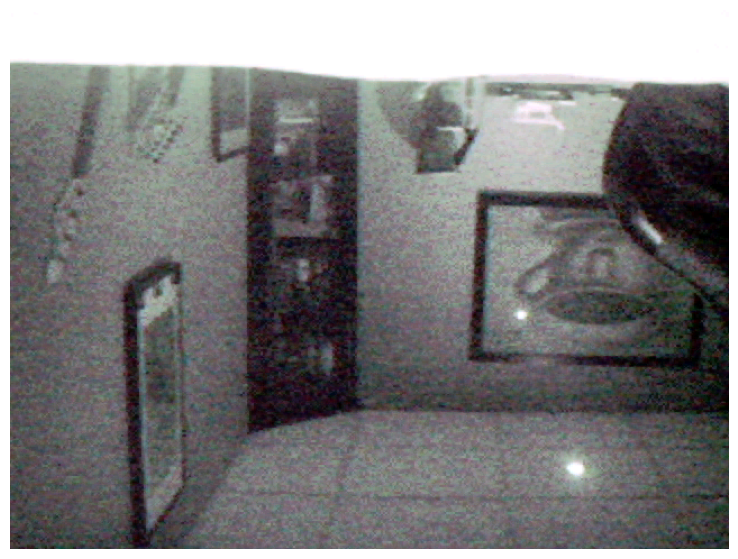

In [24]:
# Cell 4: Load + render
img565 = load_rgb565(DUMP_PATH, WIDTH, HEIGHT, fmt=FORMAT, pixel_order=PIXEL_ORDER)

if FLIP_H:
    img565 = img565[:, ::-1]
if FLIP_V:
    img565 = img565[::-1, :]

rgb = rgb565_to_rgb888(img565)

plt.figure(figsize=(10, 7))
plt.imshow(rgb)
plt.axis("off")
# plt.title(f"{WIDTH}x{HEIGHT} RGB565 (format={FORMAT}, order={PIXEL_ORDER})")
plt.show()

if SAVE_PNG:
    plt.imsave(OUT_PNG_PATH, rgb)
    print(f"Saved: {OUT_PNG_PATH}")

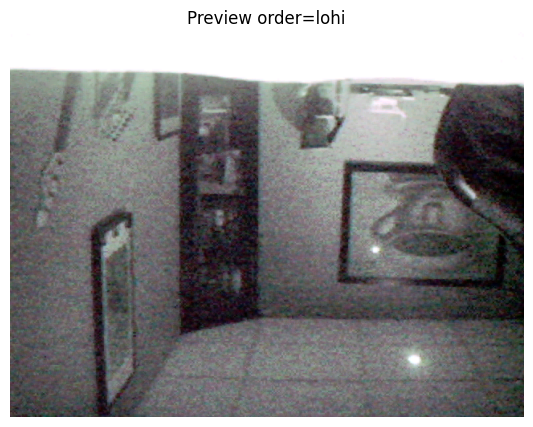

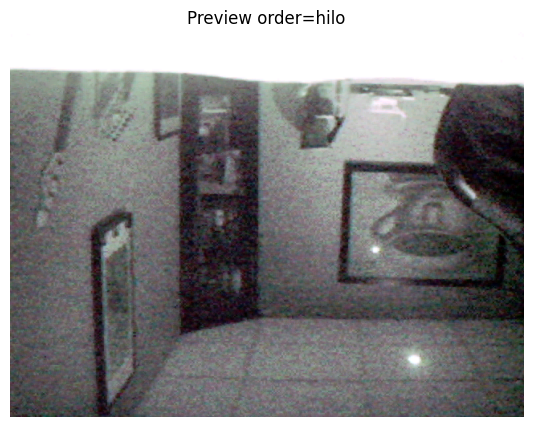

In [25]:
# Cell 5 (optional): quick sanity check for pixel order
# If the image looks like color channels are "alternating" every pixel, try the other order:
for order in ["lohi", "hilo"]:
    img565_test = load_rgb565(DUMP_PATH, WIDTH, HEIGHT, fmt=FORMAT, pixel_order=order)
    if FLIP_H: img565_test = img565_test[:, ::-1]
    if FLIP_V: img565_test = img565_test[::-1, :]
    rgb_test = rgb565_to_rgb888(img565_test)
    plt.figure(figsize=(8, 5))
    plt.imshow(rgb_test)
    plt.axis("off")
    plt.title(f"Preview order={order}")
    plt.show()